# 8.6 Exercise 1 – SVM with a Quadratic Distribution

Generate a random 2D dataset with a quadratic/non-linear decision boundary and classify it using an SVM with an RBF kernel.

In [1]:
#ch.sc.u4cse24145
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

np.random.seed(42)

n = 300
X = np.random.uniform(-3, 3, (n, 2))
y = (X[:, 1] > X[:, 0]**2 - 1).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Dataset shape:", X.shape)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Dataset shape: (300, 2)
Training samples: 240
Testing samples: 60


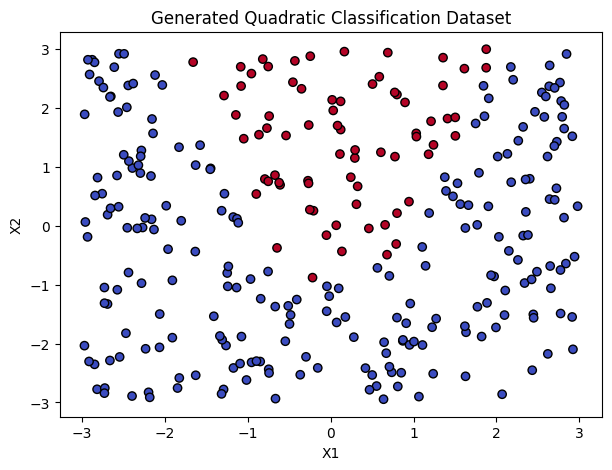

In [2]:
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k")
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Generated Quadratic Classification Dataset")
plt.show()


### Train SVM

An RBF-kernel SVM is used because the classes are separated by a non-linear quadratic boundary.

In [3]:
model = SVC(kernel="rbf", C=1.0, gamma="scale")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        46
           1       1.00      1.00      1.00        14

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



<Figure size 700x500 with 0 Axes>

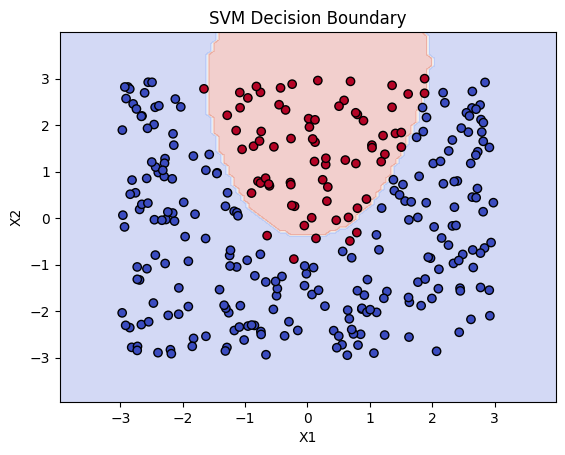

In [4]:
from sklearn.inspection import DecisionBoundaryDisplay

plt.figure(figsize=(7, 5))
DecisionBoundaryDisplay.from_estimator(
    model,
    X,
    response_method="predict",
    alpha=0.25,
    cmap="coolwarm"
)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k")
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("SVM Decision Boundary")
plt.show()


### Result

The SVM learns a non-linear decision boundary and classifies the generated quadratic dataset.